<a href="https://colab.research.google.com/github/IgorIvanoff/IgorIvanoff/blob/main/Radioquimuica_pratica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

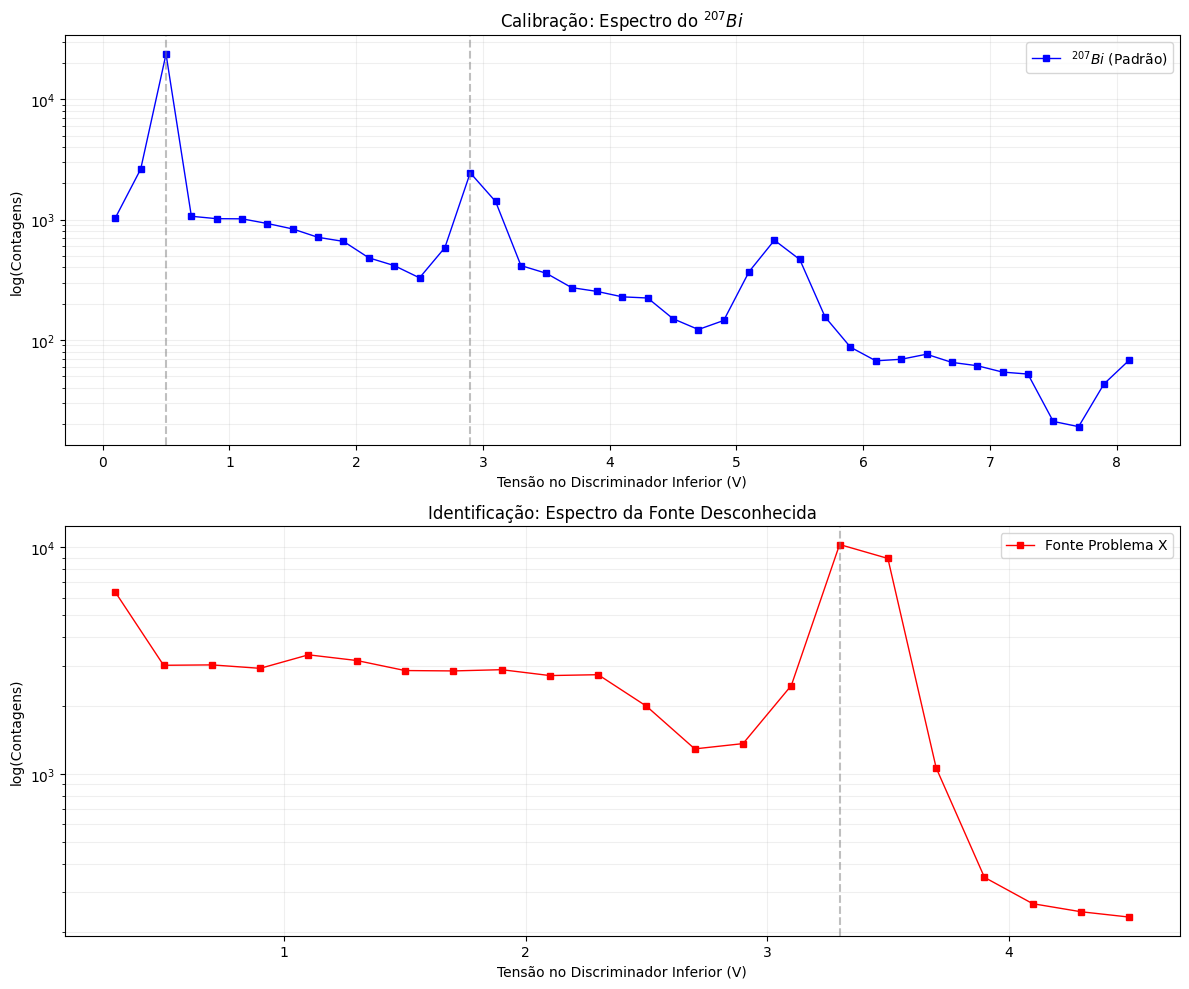

--- RESULTADOS EXPERIMENTAIS ---
Equação de Calibração: E(keV) = 250.00 * V + 409.33

FONTE X:
  Tensão do Fotopico: 3.3 V
  Energia Correspondente: 1234.33 keV

ANÁLISE DE RESOLUÇÃO (Pico 0.5V):
  Resolução estimada: 40.0%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Dados coletados ---
v_bi = np.arange(0.1, 8.2, 0.2)
counts_bi = [1033, 2628, 23789, 1066, 1018, 1015, 928, 836, 712, 659, 481, 415, 328,
             585, 2449, 1415, 415, 358, 272, 253, 228, 223, 150, 122, 145, 369,
             674, 466, 155, 87, 67, 69, 76, 65, 61, 54, 52, 21, 19, 43, 68]

v_x = np.arange(0.3, 4.6, 0.2)
counts_x = [6335, 3013, 3025, 2921, 3351, 3163, 2856, 2845, 2881, 2714, 2738, 1988,
            1288, 1359, 2453, 10284, 8927, 1062, 349, 267, 246, 233]

# --- 2. Calibração Linear ---
# Energias teóricas do Bi-207: 570 keV, 1063 keV e 1770 keV
v_picos = np.array([0.5, 2.9, 5.3]); e_picos = np.array([570, 1063, 1770])
coeffs = np.polyfit(v_picos, e_picos, 1); cal_func = np.poly1d(coeffs)

# --- 3. Gráficos ---
plt.figure(figsize=(12, 10))

# Espectro do Bi-207
plt.subplot(2, 1, 1)
plt.semilogy(v_bi, counts_bi, 'b-s', markersize=4, linewidth=1, label='${}^{207}Bi$ (Padrão)')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=2.9, color='gray', linestyle='--', alpha=0.5)
plt.title('Calibração: Espectro do ${}^{207}Bi$')
plt.xlabel('Tensão no Discriminador Inferior (V)')
plt.ylabel('log(Contagens)'); plt.grid(True, which="both", ls="-", alpha=0.2); plt.legend()

# Espectro da Fonte X
plt.subplot(2, 1, 2)
plt.semilogy(v_x, counts_x, 'r-s', markersize=4, linewidth=1, label='Fonte Problema X')
plt.axvline(x=3.3, color='gray', linestyle='--', alpha=0.5)
plt.title('Identificação: Espectro da Fonte Desconhecida')
plt.xlabel('Tensão no Discriminador Inferior (V)')
plt.ylabel('log(Contagens)'); plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(); plt.tight_layout(); plt.show()
# --- 4. Relatório de Cálculos ---
print(f"--- RESULTADOS EXPERIMENTAIS ---")
print(f"Equação de Calibração: E(keV) = {coeffs[0]:.2f} * V + {coeffs[1]:.2f}")
# Identificação da Fonte X
v_pico_x = 3.3; energia_x = cal_func(v_pico_x)
print(f"\nFONTE X:"); print(f"  Tensão do Fotopico: {v_pico_x} V")
print(f"  Energia Correspondente: {energia_x:.2f} keV")
#(R = deltaV / V) para o pico principal do Bi [cite: 106]; meia altura de 23789 (~11894).
# DeltaV é aprox em(0.2V) ou interpolado.
resolucao_bi = (0.2 / 0.5) * 100
print(f"\nANÁLISE DE RESOLUÇÃO (Pico 0.5V):"); print(f"  Resolução estimada: {resolucao_bi:.1f}%")